# Binary Search-Based Speech/Silence Segmentation

**Student:** Le Nhat Phong  
**Algorithm:** Binary Search Method (Energy-based, Algorithm 1)

This notebook presents the implementation and experimental evaluation of an energy-based speech/silence segmentation method whose decision threshold is found by binary search.


## 1. Objective

The objective is to segment each test speech signal into **speech** and **silence** regions and evaluate the detected speech boundaries against the provided ground truth.

The experiment uses four test signals and reports:

- detected speech boundaries;
- intermediate binary-search thresholding results;
- Mean Absolute Error (MAE);
- Root Mean Square Error (RMSE);
- missing and extra detected boundaries.


## 2. Method Overview

The implemented processing pipeline is:

1. **Preprocess** the signal: remove the DC component and normalize the peak amplitude to 1.
2. Frame the audio signal using a **25 ms frame length** and **10 ms frame shift**.
3. Extract one energy feature per frame (the trained choice is **Mean Absolute amplitude, MA**).
4. Smooth the feature track with a **moving average** (9 frames in the trained parameters).
5. On the training signals, pool the feature values of all **speech frames (S)** and all **silence frames (Q)** using the ground-truth labels.
6. Find the **overlap region** `[lo, hi]` between the two classes, where `lo` is the 1st percentile of S and `hi` is the 99th percentile of Q.
7. Define the error function:

   `F(T) = (fraction of silence frames > T) - (fraction of speech frames <= T)`

   `F(T)` decreases as `T` increases, so `F(T) = 0` is solved by **binary search** on `[lo, hi]`. The result is one **shared threshold T**.
8. Classify a frame as speech when its feature value is greater than `T`.
9. Post-process: shift the speech onset/offset (`trim_on`, `trim_off`), drop speech segments shorter than `min_speech_ms`, and merge silence intervals shorter than **200 ms**.
10. Extract the final speech boundaries.
11. Compare the detected boundaries with the ground truth.


## 3. Implementation

This notebook is **self-contained**: the code of the whole project (`src/binary_search`, `src/common`, `config`) is merged into a single file that runs sequentially from top to bottom (**Run All**). The cells of this section only **define** the functions and the algorithm class; the experiment itself starts in Section 4.

### 3.1 Setup and libraries


In [1]:
# ====== Libraries ======
import glob          # find files by name pattern (e.g. *.wav)
import itertools     # Cartesian product for the hyperparameter grid
import json          # read/write the trained-parameter file
import os            # file / directory path handling
import wave          # read WAV (PCM) audio files

import numpy as np               # numerical computation on arrays
import matplotlib.pyplot as plt  # plotting results

# ====== EDIT THESE PATHS TO MATCH YOUR MACHINE ======
TRAIN_DIR = os.path.join("data", "TinHieuHuanLuyen")   # training folder: .wav + .lab pairs
TEST_DIR  = os.path.join("data", "TinHieuKiemThu")     # test folder: .wav + .lab pairs
PARAMS_PATH = "trained_parameters.json"                # where the trained parameters are saved
RESULT_DIR = os.path.join("results", "binary_search")  # all tables (CSV) and figures (PNG) are saved here

### 3.2 Preprocessing and features


In [2]:
# ---------------- Fixed parameters set by the assignment (must NOT be optimized) ----------------
FRAME_MS = 25.0     # frame length (ms)
HOP_MS = 10.0       # frame shift (ms)
MIN_SIL_MS = 200.0  # minimum length of a silence segment (ms)
EPS_LOG = 1e-6      # small constant to avoid log(0)


def preprocess(x):
    """Preprocessing: remove the DC component, then normalize the peak amplitude to 1.

    Args:
        x (array-like): raw signal samples.
    Returns:
        ndarray (float64): DC-free signal divided by its peak amplitude;
        an all-zero signal is returned unchanged.
    """
    # Convert to float64 and subtract the mean to remove DC
    x = np.asarray(x, dtype=np.float64)
    x = x - np.mean(x)
    # Take the peak amplitude (0 for an empty signal) and normalize to [-1, 1]
    peak = np.max(np.abs(x)) if len(x) else 0.0
    return x / peak if peak > 0 else x


def frame_params(fs):
    """Convert the 25 ms frame length and 10 ms frame shift to samples for this file's sampling rate.

    Args:
        fs (int): sampling rate (Hz).
    Returns:
        (frame_len, hop): frame length and frame shift in samples.
    """
    return int(round(FRAME_MS * fs / 1000.0)), int(round(HOP_MS * fs / 1000.0))


def num_frames(n_samples, frame_len, hop):
    """Number of frames (the last frame lies fully inside the signal; at least 1 frame).

    Args:
        n_samples (int): number of samples in the signal.
        frame_len (int): frame length (samples).
        hop (int): frame shift (samples).
    Returns:
        int: number of frames.
    """
    if n_samples < frame_len:
        return 1
    return 1 + (n_samples - frame_len) // hop


def frame_centers(n_frames, frame_len, hop, fs):
    """Compute the center time of every frame.

    Args:
        n_frames (int): number of frames.
        frame_len (int): frame length (samples).
        hop (int): frame shift (samples).
        fs (int): sampling rate (Hz).
    Returns:
        ndarray: center time of each frame (seconds), length n_frames.
    """
    return (np.arange(n_frames) * hop + frame_len / 2.0) / fs


def frame_features(x, fs, kind="MA"):
    """Per-frame energy features via cumulative sums (no frame matrix is built).

    Args:
        x (ndarray): preprocessed signal.
        fs (int): sampling rate (Hz).
        kind (str): 'MA' = mean(|x|), 'RMS' = sqrt(mean(x^2)), 'STE' = sum(x^2).
    Returns:
        ndarray: feature value of each frame.
    """
    # Get the frame size; zero-pad if the signal is shorter than one frame
    frame_len, hop = frame_params(fs)
    if len(x) < frame_len:
        x = np.concatenate((x, np.zeros(frame_len - len(x))))
    # Start / end sample index of every frame
    nf = num_frames(len(x), frame_len, hop)
    starts = np.arange(nf) * hop
    ends = starts + frame_len

    # MA: mean absolute amplitude, computed quickly from the cumulative sum of |x|
    if kind == "MA":
        c = np.concatenate(([0.0], np.cumsum(np.abs(x))))
        return (c[ends] - c[starts]) / frame_len

    # STE / RMS: sum of squares per frame from the cumulative sum of x^2
    c2 = np.concatenate(([0.0], np.cumsum(x * x)))
    ste = np.maximum(c2[ends] - c2[starts], 0.0)
    if kind == "STE":
        return ste
    if kind == "RMS":
        return np.sqrt(ste / frame_len)
    raise ValueError("kind must be MA, RMS or STE")


def moving_average(a, length):
    """Smooth a sequence with a moving average (odd window, edge values replicated).

    Args:
        a (ndarray): input sequence.
        length (int): window length (should be odd so the output has the same length as the input).
    Returns:
        ndarray: smoothed sequence (returned unchanged if length <= 1).
    """
    if length <= 1:
        return a
    # Pad h edge values on both sides so no samples are lost at the borders
    h = length // 2
    p = np.concatenate((np.full(h, a[0]), a, np.full(h, a[-1])))
    # Moving average via cumulative sum
    c = np.concatenate(([0.0], np.cumsum(p)))
    return (c[length:] - c[:-length]) / length


def compute_feature_track(x_norm, fs, kind, use_log, smooth_len):
    """Final feature track: per-frame feature -> smoothing -> (optional) log10.

    Args:
        x_norm (ndarray): normalized signal.
        fs (int): sampling rate (Hz).
        kind (str): feature type ('MA', 'RMS', 'STE').
        use_log (bool): True to take log10 (EPS_LOG is added first).
        smooth_len (int): smoothing window length (frames).
    Returns:
        ndarray: processed feature value of each frame.
    """
    feat = moving_average(frame_features(x_norm, fs, kind), smooth_len)
    if use_log:
        feat = np.log10(feat + EPS_LOG)
    return feat

### 3.3 Threshold search by binary search


In [3]:
def find_overlap_region(S, Q, trim=1.0):
    """Find the overlap region between speech and silence features.

    Args:
        S (ndarray): features of speech frames.
        Q (ndarray): features of silence frames.
        trim (float): percentage cut at each end to discard outliers.
    Returns:
        (lo, hi): lo = trim% percentile of S, hi = (100 - trim)% percentile of Q.
    """
    return np.percentile(S, trim), np.percentile(Q, 100.0 - trim)


def confusion_error(T, f, g):
    """Error function F(T) = (fraction of silence frames > T) - (fraction of speech frames <= T).
    F decreases monotonically with T, so F(T) = 0 can be solved by bisection.

    Args:
        T (float): threshold under test.
        f (ndarray): speech-frame features inside the overlap region.
        g (ndarray): silence-frame features inside the overlap region.
    Returns:
        (F, (n_f_below, n_g_above)): the value F(T) and two counts used to detect convergence.
    """
    n_f_below = int(np.sum(f <= T))   # speech frames wrongly classified as silence
    n_g_above = int(np.sum(g > T))    # silence frames wrongly classified as speech
    return n_g_above / len(g) - n_f_below / len(f), (n_f_below, n_g_above)


def binary_search_threshold(f, g, lo, hi, eps_rel=1e-4, max_iter=60, patience=3):
    """Find the threshold T with F(T) = 0 by binary search on [lo, hi].

    Args:
        f, g (ndarray): speech / silence features inside the overlap region.
        lo, hi (float): ends of the search interval.
        eps_rel (float): stopping width, relative to (hi - lo).
        max_iter (int): maximum number of iterations.
        patience (int): stop early after this many consecutive iterations with unchanged counts.
    Returns:
        float: the threshold T (midpoint of the final interval).
    """
    # Initialize the search interval, stopping tolerance and the first threshold at the midpoint
    t_min, t_max = lo, hi
    eps = eps_rel * (hi - lo)
    T = 0.5 * (t_min + t_max)
    last, same = None, 0

    for _ in range(max_iter):
        # Error at T: F > 0 means T is too low (many silence frames exceed T)
        F, counts = confusion_error(T, f, g)
        if F > 0:
            t_min = T
        else:
            t_max = T
        # Stop when the interval is narrow enough or the counts repeat for `patience` iterations
        if t_max - t_min < eps:
            break
        same = same + 1 if counts == last else 0
        last = counts
        if same >= patience:
            break
        T = 0.5 * (t_min + t_max)
    return 0.5 * (t_min + t_max)


def train_threshold(S, Q, trim=1.0):
    """Find the threshold T from speech-frame (S) and silence-frame (Q) features of the training set.

    Args:
        S (ndarray): features of speech frames.
        Q (ndarray): features of silence frames.
        trim (float): percentage cut when finding the overlap region.
    Returns:
        (T, sep): T is the threshold; sep = mean(S) - mean(Q) is used to set the hysteresis width.
    """
    # Class separation and the overlap region of the two classes
    S, Q = np.asarray(S), np.asarray(Q)
    sep = float(np.mean(S) - np.mean(Q))
    lo, hi = find_overlap_region(S, Q, trim)
    # Classes do not overlap: use the midpoint of the gap as the threshold
    if lo >= hi:
        return 0.5 * (lo + hi), sep
    # Keep the frames inside the overlap region; if a class is empty use the midpoint
    f = S[(S >= lo) & (S <= hi)]
    g = Q[(Q >= lo) & (Q <= hi)]
    if len(f) == 0 or len(g) == 0:
        return 0.5 * (lo + hi), sep
    # Find the threshold by binary search on the overlap region
    return binary_search_threshold(f, g, lo, hi), sep

### 3.4 Frame labeling, post-processing and boundary conversion


In [4]:
def classify_frames(feat, T, sep, hyst):
    """Label every frame: True = speech, False = silence.

    Args:
        feat (ndarray): feature track of the frames.
        T (float): decision threshold.
        sep (float): class separation (mean(S) - mean(Q)), multiplied by hyst.
        hyst (float): hysteresis factor; hyst = 0 uses a single threshold, hyst > 0 uses two
            thresholds (on at T + hyst*sep, off at T - hyst*sep).
    Returns:
        ndarray bool: speech mask of the frames.
    """
    # Single-threshold case: compare directly with T
    if hyst <= 0:
        return feat > T
    # Dual-threshold case: compute the on-threshold (t_on) and off-threshold (t_off)
    t_on, t_off = T + hyst * sep, T - hyst * sep
    mask = np.zeros(len(feat), dtype=bool)
    state = False
    # Scan sequentially: while speaking, switch off only below t_off; while silent, switch on only above t_on
    for k, v in enumerate(feat.tolist()):
        if state:
            if v < t_off:
                state = False
        elif v > t_on:
            state = True
        mask[k] = state
    return mask


def dilate(mask, e):
    """Extend speech regions by e frames on each side.

    Args:
        mask (ndarray bool): speech mask.
        e (int): number of frames to extend on each side (e <= 0 leaves the mask unchanged).
    Returns:
        ndarray bool: mask after dilation.
    """
    if e <= 0:
        return mask
    # Cumulative sum of the mask to count speech frames in the window [i-e, i+e] quickly
    n = len(mask)
    c = np.concatenate(([0], np.cumsum(mask.astype(np.int64))))
    lo = np.maximum(np.arange(n) - e, 0)
    hi = np.minimum(np.arange(n) + e + 1, n)
    # A frame is speech if the window contains at least one speech frame
    return (c[hi] - c[lo]) > 0


def trim_speech(mask, trim_on, trim_off):
    """Shift speech onsets later by trim_on frames and offsets earlier by trim_off frames.
    Negative values extend the speech region. Boundaries at the very start/end of the file are not moved.

    Args:
        mask (ndarray bool): speech mask.
        trim_on (int): frames to shift the speech onset (positive = later).
        trim_off (int): frames to shift the speech offset (positive = earlier).
    Returns:
        ndarray bool: mask after shifting the boundaries.
    """
    if trim_on == 0 and trim_off == 0:
        return mask
    n = len(mask)
    out = np.zeros(n, dtype=bool)
    # For every speech run: shift its start and end, then clamp to [0, n]
    for s, e, v in get_runs(mask):
        if not v:
            continue
        s2 = s if s == 0 else min(max(s + trim_on, 0), n)
        e2 = e if e == n else min(max(e - trim_off, 0), n)
        # Keep the run only if it still has positive length after shifting
        if e2 > s2:
            out[s2:e2] = True
    return out


def get_runs(mask):
    """Split a mask into runs of identical labels.

    Args:
        mask (ndarray bool): per-frame label mask.
    Returns:
        list[(first_frame, last_frame_exclusive, label)]: runs, each given as its first frame,
        its last frame (exclusive) and its bool label.
    """
    # Find the positions where the label changes to get the start/end of every run
    m = mask.astype(np.int8)
    change = np.nonzero(m[1:] != m[:-1])[0] + 1
    starts = np.concatenate(([0], change))
    ends = np.concatenate((change, [len(m)]))
    return [(int(s), int(e), bool(m[s])) for s, e in zip(starts, ends)]


def remove_short_runs(mask, value, min_frames, include_edges=True):
    """Flip the label of runs labeled `value` that are shorter than min_frames.

    Args:
        mask (ndarray bool): per-frame label mask.
        value (bool): label of the runs to check (True = speech, False = silence).
        min_frames (int): minimum run length (frames) to keep a run.
        include_edges (bool): False to skip runs at the start/end of the file.
    Returns:
        ndarray bool: mask after removing the too-short runs.
    """
    out = mask.copy()
    runs = get_runs(mask)
    for i, (s, e, v) in enumerate(runs):
        # Skip runs with another label or runs that are already long enough
        if v != value or (e - s) >= min_frames:
            continue
        # Optionally leave the runs at both ends of the file untouched
        if (i == 0 or i == len(runs) - 1) and not include_edges:
            continue
        # Flip the label of the too-short run
        out[s:e] = not value
    return out


def mask_to_segments(mask, fs, n_samples):
    """Convert the frame mask to a list of boundaries and a list of segments in time.

    Args:
        mask (ndarray bool): per-frame speech mask.
        fs (int): sampling rate (Hz).
        n_samples (int): number of samples of the original signal (to get the file duration).
    Returns:
        (boundaries, segments): boundaries is the list of boundary times (seconds);
        segments is the list of (t_start, t_end, 'speech' | 'sil').
    """
    # Get the consecutive runs and the file duration (seconds)
    frame_len, hop = frame_params(fs)
    dur = n_samples / fs
    runs = get_runs(mask)
    # A boundary lies midway between the centers of the two adjacent frames where the label changes
    boundaries = [(s * hop - hop / 2.0 + frame_len / 2.0) / fs for s, _, _ in runs[1:]]
    # Assemble segments [edges[i], edges[i+1]] with their labels
    edges = [0.0] + boundaries + [dur]
    segments = [(edges[i], edges[i + 1], "speech" if runs[i][2] else "sil")
                for i in range(len(runs))]
    return boundaries, segments


def predict_file(x, fs, params):
    """Whole segmentation pipeline for one signal (see BinarySearchAlgorithm.predict).

    Args:
        x (ndarray): raw signal.
        fs (int): sampling rate (Hz).
        params (dict): trained parameters (kind, use_log, smooth_len, T, sep, hyst,
            trim_on, trim_off, min_speech_ms; expand if present).
    Returns:
        dict with: xn (normalized signal), feat (feature track), mask_raw (raw frame labels),
        mask_exp (after boundary shifting), mask (final labels), boundaries (seconds), segments.
    """
    # Step 1: preprocess, compute the feature track and label frames with the threshold
    xn = preprocess(x)
    feat = compute_feature_track(xn, fs, params["kind"], params["use_log"],
                                 params["smooth_len"])
    mask_raw = classify_frames(feat, params["T"], params["sep"], params["hyst"])

    # Step 2: post-processing - shift boundaries (trim), drop very short speech,
    # then fill silence gaps shorter than 200 ms (assignment rule)
    mask_exp = dilate(mask_raw, int(params.get("expand", 0)))      # kept for backward compatibility
    mask_exp = trim_speech(mask_exp, int(params.get("trim_on", 0)),
                           int(params.get("trim_off", 0)))
    min_sp = int(np.ceil(params["min_speech_ms"] / HOP_MS))
    mask_exp = remove_short_runs(mask_exp, True, min_sp)
    min_sil = int(np.ceil(MIN_SIL_MS / HOP_MS))
    mask = remove_short_runs(mask_exp, False, min_sil)

    # Step 3: convert the final mask to boundaries (seconds) and segments
    boundaries, segments = mask_to_segments(mask, fs, len(x))
    return {"xn": xn, "feat": feat, "mask_raw": mask_raw, "mask_exp": mask_exp,
            "mask": mask, "boundaries": boundaries, "segments": segments}

### 3.5 Data loading (WAV + LAB)


In [5]:
# Hyperparameter grid (kept small for speed; can be adjusted)
GRID = {
    "kind": ["MA", "RMS"],            # type of energy feature
    "use_log": [False, True],         # whether to take log10
    "smooth_len": [1, 3, 5, 9],       # smoothing window length (frames)
    "hyst": [0.0, 0.15],              # hysteresis factor (0 = single threshold)
    "min_speech_ms": [0, 50, 100],    # minimum speech-segment length (ms)
}
# Shift of the speech onset/offset (frames of 10 ms; negative = extend speech), refined after the main grid
TRIM_RANGE = range(-2, 7)   # -20 ms ... +60 ms

# Per the assignment README: sil = silence; v (voiced) and uv (unvoiced) both count as SPEECH
SIL_LABELS = {"sil"}


# Data reading
# ---------------------------------------------------------------------
def read_wav(path):
    """Read a PCM WAV file (8/16/24/32 bit) and convert it to a mono signal in [-1, 1].

    Args:
        path (str): path of the .wav file.
    Returns:
        (x, fs): x is a mono float64 array in [-1, 1], fs is the sampling rate (Hz).
    """
    # Open the file and read its parameters (channels, sample width, sampling rate) and raw data
    with wave.open(path, "rb") as w:
        n_ch, sw = w.getnchannels(), w.getsampwidth()
        fs, n = w.getframerate(), w.getnframes()
        raw = w.readframes(n)
    # Decode the raw bytes according to the sample width and normalize to [-1, 1]
    if sw == 1:
        x = (np.frombuffer(raw, dtype=np.uint8).astype(np.float64) - 128.0) / 128.0
    elif sw == 2:
        x = np.frombuffer(raw, dtype="<i2").astype(np.float64) / 32768.0
    elif sw == 3:
        b = np.frombuffer(raw, dtype=np.uint8).reshape(-1, 3).astype(np.int32)
        v = b[:, 0] | (b[:, 1] << 8) | (b[:, 2] << 16)
        v = np.where(v >= 2 ** 23, v - 2 ** 24, v)
        x = v.astype(np.float64) / 2 ** 23
    elif sw == 4:
        x = np.frombuffer(raw, dtype="<i4").astype(np.float64) / 2 ** 31
    else:
        raise ValueError("Unsupported sample width: %d bytes" % sw)
    # Multi-channel: average the channels to get mono
    if n_ch > 1:
        x = x[: len(x) // n_ch * n_ch].reshape(-1, n_ch).mean(axis=1)
    return x, fs


def read_lab(path):
    """Read a .lab file (t_start t_end label); the F0mean/F0std lines are skipped.

    Args:
        path (str): path of the .lab file.
    Returns:
        list[(t_start, t_end, is_speech)]: label segments, is_speech=False for 'sil'.
    """
    segs = []
    with open(path, "r", encoding="utf-8", errors="ignore") as fh:
        for line in fh:
            # Skip lines with fewer than 3 columns or whose first two columns are not numbers (F0mean, F0std...)
            tok = line.strip().split()
            if len(tok) < 3:
                continue
            try:
                s, e = float(tok[0]), float(tok[1])
            except ValueError:
                continue
            # Store the segment with its speech flag (any label other than 'sil' is speech)
            segs.append((s, e, tok[2].strip().lower() not in SIL_LABELS))
    return segs


def lab_boundaries(segs):
    """Ground-truth boundaries = label changes between speech and silence.
    A change between v and uv does not count as a boundary.

    Args:
        segs (list): output of read_lab.
    Returns:
        list[float]: ground-truth boundary times (seconds).
    """
    return [segs[i][0] for i in range(1, len(segs)) if segs[i][2] != segs[i - 1][2]]


def lab_frame_mask(segs, centers):
    """Ground-truth label of every frame (True = speech), evaluated at the frame centers.

    Args:
        segs (list): output of read_lab.
        centers (ndarray): frame center times (seconds).
    Returns:
        ndarray bool: ground-truth label of each frame.
    """
    mask = np.zeros(len(centers), dtype=bool)
    # A frame whose center lies inside a speech segment is labeled True
    for s, e, is_sp in segs:
        if is_sp:
            mask[(centers >= s) & (centers < e)] = True
    return mask


def boundary_errors(gt_b, pr_b, cap_ms):
    """Distance (ms) from each ground-truth boundary to the nearest predicted boundary, and vice versa.

    Args:
        gt_b (list): ground-truth boundaries (seconds).
        pr_b (list): predicted boundaries (seconds).
        cap_ms (float): error assigned when one side has no boundary at all (ms).
    Returns:
        (e_gt, e_pr): e_gt = error from each ground-truth boundary to the nearest predicted one,
        e_pr = error from each predicted boundary to the nearest ground-truth one (ms).
    """
    gt, pr = np.asarray(gt_b, float), np.asarray(pr_b, float)
    # One side empty: assign the maximum error cap_ms
    if len(gt) == 0:
        return np.array([]), np.full(len(pr), cap_ms)
    if len(pr) == 0:
        return np.full(len(gt), cap_ms), np.array([])
    # Distance matrix of all (ground truth, prediction) pairs; take the minimum along each axis
    d = np.abs(gt[:, None] - pr[None, :]) * 1000.0
    return d.min(axis=1), d.min(axis=0)


def load_one(wav_path, lab_path):
    """Load one wav + lab pair and precompute the quantities used in training.

    Args:
        wav_path (str): path of the .wav file.
        lab_path (str): path of the matching .lab file.
    Returns:
        dict with: name, x (raw), xn (normalized), fs, dur (seconds),
        gt_b (ground-truth boundaries), gt_mask (ground-truth per-frame labels).
    """
    # Read the signal and the labels
    x, fs = read_wav(wav_path)
    dur = len(x) / fs
    segs = read_lab(lab_path)
    # Compute the frame centers to build the per-frame ground-truth labels
    frame_len, hop = frame_params(fs)
    nf = num_frames(len(x), frame_len, hop)
    centers = frame_centers(nf, frame_len, hop, fs)
    return {"name": os.path.splitext(os.path.basename(wav_path))[0],
            "x": x, "xn": preprocess(x), "fs": fs, "dur": dur,
            "gt_b": lab_boundaries(segs), "gt_mask": lab_frame_mask(segs, centers)}


def load_dataset(training_files, training_labs):
    """Load a list of (wav, lab) pairs. Both lists must have the same length and order.

    Args:
        training_files (list[str]): paths of the .wav files.
        training_labs (list[str]): paths of the matching .lab files.
    Returns:
        list[dict]: load_one result for every pair.
    """
    if len(training_files) != len(training_labs):
        raise ValueError("Number of WAV files (%d) differs from number of LAB files (%d)"
                         % (len(training_files), len(training_labs)))
    return [load_one(w, l) for w, l in zip(training_files, training_labs)]


def find_pairs(folder):
    """Find *.wav + *.lab pairs with the same name in a folder (files without .lab are skipped).

    Args:
        folder (str): path of the data folder.
    Returns:
        (files, labs): lists of .wav and matching .lab paths (same order).
    """
    # Check the folder exists, then list the .wav files (case-insensitive extension)
    if not os.path.isdir(folder):
        raise SystemExit("ERROR: data folder not found: %s" % os.path.abspath(folder))
    wavs = sorted(set(glob.glob(os.path.join(folder, "*.wav"))
                      + glob.glob(os.path.join(folder, "*.WAV"))))
    files, labs = [], []
    # Keep only the .wav files that have a .lab file with the same name
    for w in wavs:
        lab = os.path.splitext(w)[0] + ".lab"
        if os.path.exists(lab):
            files.append(w)
            labs.append(lab)
        else:
            print("  [skipped] missing .lab file for", os.path.basename(w))
    if not files:
        raise SystemExit("ERROR: no .wav + .lab pairs found in %s" % folder)
    return files, labs

### 3.6 Training functions

The training functions (hyperparameter grid and boundary-shift refinement) are only executed when `RETRAIN = True` in Section 4. During the normal run, the frozen parameters are used.


In [6]:
# Training
# ---------------------------------------------------------------------
def pooled_class_features(data, tracks):
    """Pool frame features of all files into S (speech) and Q (silence) using the ground-truth labels.

    Args:
        data (list[dict]): data from load_dataset (needs the key 'gt_mask').
        tracks (list[ndarray]): feature track of each file (same order as data).
    Returns:
        (S, Q): S = features of speech frames, Q = features of silence frames.
    """
    S = np.concatenate([t[d["gt_mask"][: len(t)]] for d, t in zip(data, tracks)])
    Q = np.concatenate([t[~d["gt_mask"][: len(t)]] for d, t in zip(data, tracks)])
    return S, Q


def objective(data, params):
    """Score (ms, lower is better) = mean of MAE(ground truth -> prediction) and MAE(prediction -> ground truth).
    The second term penalizes producing extra boundaries.

    Args:
        data (list[dict]): training data from load_dataset.
        params (dict): parameter set to evaluate.
    Returns:
        float: the score (ms).
    """
    # Predict every file and collect the errors in both directions
    e_gt, e_pr = [], []
    for d in data:
        res = predict_file(d["x"], d["fs"], params)
        a, b = boundary_errors(d["gt_b"], res["boundaries"], d["dur"] * 1000.0)
        e_gt.append(a)
        e_pr.append(b)
    # MAE of each direction, then their average
    e_gt, e_pr = np.concatenate(e_gt), np.concatenate(e_pr)
    m1 = np.mean(e_gt) if len(e_gt) else 0.0
    m2 = np.mean(e_pr) if len(e_pr) else 0.0
    return 0.5 * (m1 + m2)


def grid_search(data, verbose=True):
    """Find the best parameter set on the hyperparameter grid GRID.

    Args:
        data (list[dict]): training data from load_dataset.
        verbose (bool): True to print progress.
    Returns:
        (best_params, best_score_ms): the best parameter set and its training score.
    """
    best, best_score = None, float("inf")

    # Outer loop: for each (kind, use_log, smooth_len) compute the features and find the threshold T
    for kind, use_log, sm in itertools.product(GRID["kind"], GRID["use_log"],
                                               GRID["smooth_len"]):
        tracks = [compute_feature_track(d["xn"], d["fs"], kind, use_log, sm) for d in data]
        S, Q = pooled_class_features(data, tracks)
        T, sep = train_threshold(S, Q)          # binary search on the pooled features

        # Inner loop: try the post-processing parameters and keep the set with the lowest score
        for hy, ms in itertools.product(GRID["hyst"], GRID["min_speech_ms"]):
            params = {"kind": kind, "use_log": use_log, "smooth_len": sm,
                      "T": float(T), "sep": float(sep), "hyst": hy,
                      "trim_on": 0, "trim_off": 0, "min_speech_ms": ms}
            score = objective(data, params)
            if score < best_score:
                best, best_score = params, score

        # Print progress after every (kind, use_log, smooth_len) combination
        if verbose:
            print("  %-3s log=%-5s smooth=%d  T=%.5f | best so far: %.1f ms"
                  % (kind, use_log, sm, T, best_score))
    return best, best_score


def refine_trim(data, params, verbose=True):
    """After the main grid: find the best boundary shift (trim_on, trim_off) on the training set.

    Args:
        data (list[dict]): training data from load_dataset.
        params (dict): best parameter set from grid_search.
        verbose (bool): True to print the result.
    Returns:
        (best, best_score): parameter set with updated trim and its training score.
    """
    # Start from the current parameter set (trim = 0)
    best, best_score = dict(params), objective(data, params)
    # Try every (trim_on, trim_off) pair in TRIM_RANGE and keep the pair with the lowest score
    for ton, toff in itertools.product(TRIM_RANGE, TRIM_RANGE):
        p = dict(params, trim_on=ton, trim_off=toff)
        sc = objective(data, p)
        if sc < best_score:
            best, best_score = p, sc
    if verbose:
        print("Refined trim: trim_on=%d trim_off=%d | training score %.2f ms"
              % (best["trim_on"], best["trim_off"], best_score))
    return best, best_score


def train_binary_search(training_files, training_labs, verbose=True):
    """Train from the lists of WAV and LAB paths of the training set.

    Args:
        training_files (list[str]): paths of the .wav files.
        training_labs (list[str]): paths of the matching .lab files.
        verbose (bool): True to print progress and results.
    Returns:
        (params, train_score_ms): params is a JSON-able dict with kind, use_log, smooth_len, T,
        sep, hyst, trim_on, trim_off, min_speech_ms; plus the training score (ms).
    """
    # Load the training data; fail if it is empty
    data = load_dataset(training_files, training_labs)
    if not data:
        raise ValueError("Empty training set")
    if verbose:
        print("Binary Search: training on %d files" % len(data))
    # Search the grid, then refine the boundary shift
    params, score = grid_search(data, verbose)
    params, score = refine_trim(data, params, verbose)
    if verbose:
        print("Best parameters:", params, "| training score: %.2f ms" % score)
    return params, score

### 3.7 Algorithm class


In [7]:
# =====================================================================
# Algorithm class following the common interface of the project
# =====================================================================
class BinarySearchAlgorithm:
    """Algorithm 1: Binary Search (Energy-based)."""

    @property
    def name(self):
        """Display name of the algorithm (str)."""
        return "Binary Search"

    @property
    def key(self):
        """Identifier key used when saving parameters/results (str)."""
        return "binary_search"

    def train(self, training_files, training_labs):
        """Train on the training set (WAV + LAB).

        Args:
            training_files (list[str]): paths of the .wav files.
            training_labs (list[str]): paths of the matching .lab files.
        Returns:
            dict: trained parameters, can be saved as JSON.
        """
        params, _ = train_binary_search(training_files, training_labs)
        return params

    def predict(self, signal, fs, params):
        """Segment `signal` with frozen parameters (no test labels are used).

        Args:
            signal (ndarray): signal to segment.
            fs (int): sampling rate (Hz).
            params (dict): trained parameters.
        Returns:
            dict with: algorithm_name, speech_mask, segments (seconds, seconds, 'speech'/'sil'),
            boundaries_ms, feature_times, features, thresholds (T, T_on, T_off), diagnostics.
        """
        # Run the whole segmentation pipeline and compute the frame center times
        res = predict_file(signal, fs, params)
        feat = res["feat"]
        frame_len, hop = frame_params(fs)
        times = frame_centers(len(feat), frame_len, hop, fs)
        # Package the result (boundaries converted to ms) with the information needed for plotting
        return {
            "algorithm_name": self.name,
            "speech_mask": res["mask"],
            "segments": res["segments"],                       # (seconds, seconds, 'speech'/'sil')
            "boundaries_ms": [b * 1000.0 for b in res["boundaries"]],
            "feature_times": times,
            "features": {params["kind"] + (" (log10)" if params["use_log"] else ""): feat},
            "thresholds": {"T": params["T"],
                           "T_on": params["T"] + params["hyst"] * params["sep"],
                           "T_off": params["T"] - params["hyst"] * params["sep"]},
            "diagnostics": {"mask_raw": res["mask_raw"], "mask_exp": res["mask_exp"],
                            "xn": res["xn"], "params": dict(params)},
        }

### 3.8 Evaluation functions (MAE / RMSE in ms)


In [8]:
def match_boundaries(detected_boundaries_s, gt_boundaries_s):
    """Match detected boundaries to ground-truth boundaries in chronological order.

    Strategy: for each ground-truth boundary, pick the closest detected boundary that has not
    been used yet. This handles cases where the number of detected and ground-truth boundaries differ.

    Args:
        detected_boundaries_s (list[float]): detected boundaries (seconds).
        gt_boundaries_s (list[float]): ground-truth boundaries (seconds).
    Returns:
        dict with: matched_pairs ((ground truth, detected) pairs, seconds), errors_ms (absolute error
        of each pair, ms), unmatched_gt (ground-truth boundaries without a match), unmatched_det
        (detected boundaries without a match), num_gt, num_det.
    """
    det = sorted(detected_boundaries_s)
    gt = sorted(gt_boundaries_s)

    matched_pairs = []
    errors_ms = []
    used_det = set()

    # For each ground-truth boundary, find the nearest unmatched detected boundary
    for gt_b in gt:
        best_idx = None
        best_dist = float('inf')

        for i, det_b in enumerate(det):
            if i in used_det:
                continue
            dist = abs(det_b - gt_b)
            if dist < best_dist:
                best_dist = dist
                best_idx = i

        # Record the pair and its error (converted to ms)
        if best_idx is not None:
            used_det.add(best_idx)
            matched_pairs.append((gt_b, det[best_idx]))
            errors_ms.append(abs(det[best_idx] - gt_b) * 1000.0)

    # Unmatched boundaries: ground-truth boundaries that were missed and extra detections
    unmatched_gt = [gt_b for i, gt_b in enumerate(gt)
                    if not any(gt_b == pair[0] for pair in matched_pairs)]
    unmatched_det = [det[i] for i in range(len(det)) if i not in used_det]

    return {
        'matched_pairs': matched_pairs,
        'errors_ms': errors_ms,
        'unmatched_gt': unmatched_gt,
        'unmatched_det': unmatched_det,
        'num_gt': len(gt),
        'num_det': len(det),
    }


def calculate_mae(errors_ms):
    """Mean Absolute Error: MAE = mean(|predicted - ground_truth|).

    Args:
        errors_ms (list[float]): absolute boundary errors (ms).
    Returns:
        float: MAE (ms); 0.0 if the list is empty.
    """
    if len(errors_ms) == 0:
        return 0.0
    return float(np.mean(errors_ms))


def calculate_rmse(errors_ms):
    """Root Mean Squared Error: RMSE = sqrt(mean(error^2)).

    Args:
        errors_ms (list[float]): absolute boundary errors (ms).
    Returns:
        float: RMSE (ms); 0.0 if the list is empty.
    """
    if len(errors_ms) == 0:
        return 0.0
    errors = np.array(errors_ms)
    return float(np.sqrt(np.mean(errors ** 2)))


def evaluate_boundaries(detected_boundaries_s, gt_boundaries_s):
    """Full evaluation of detected vs ground-truth boundaries: match them, then compute MAE and RMSE.

    Args:
        detected_boundaries_s (list[float]): detected boundaries (seconds).
        gt_boundaries_s (list[float]): ground-truth boundaries (seconds).
    Returns:
        dict with: mae_ms, rmse_ms, errors_ms, matched_pairs, num_gt, num_det,
        num_matched (number of matched pairs), num_missing (ground-truth boundaries missed),
        num_extra (extra detected boundaries).
    """
    # Match the boundaries, then compute MAE and RMSE over the matched pairs
    matching = match_boundaries(detected_boundaries_s, gt_boundaries_s)

    mae = calculate_mae(matching['errors_ms'])
    rmse = calculate_rmse(matching['errors_ms'])

    # Collect the results together with the numbers of missing/extra boundaries
    return {
        'mae_ms': mae,
        'rmse_ms': rmse,
        'errors_ms': matching['errors_ms'],
        'matched_pairs': matching['matched_pairs'],
        'num_gt': matching['num_gt'],
        'num_det': matching['num_det'],
        'num_matched': len(matching['matched_pairs']),
        'num_missing': len(matching['unmatched_gt']),
        'num_extra': len(matching['unmatched_det']),
    }

### Parameter roles

The **25 ms frame length** and **10 ms frame shift** are fixed by the assignment. They determine how the continuous waveform is divided into short-time analysis frames.

The **200 ms minimum silence duration** is also fixed by the assignment. After frame-level classification, a silence gap shorter than this duration is merged into the surrounding speech region.

The remaining Binary Search parameters are algorithm parameters obtained during the training stage. They are kept unchanged when evaluating the test signals.


## 4. Experimental Parameters

The following parameters are fixed according to the project requirements.


In [9]:
#Fixed parameters
print("Fixed parameters")
print(f"Frame length : {FRAME_MS} ms")
print(f"Frame shift  : {HOP_MS} ms")
print(f"Min silence  : {MIN_SIL_MS} ms")

Fixed parameters
Frame length : 25.0 ms
Frame shift  : 10.0 ms
Min silence  : 200.0 ms


The trained (frozen) parameters are loaded below. The notebook **does not retrain**: set `RETRAIN = True` in the next cell only if you want to retrain from `TRAIN_DIR`.


In [10]:
#Load trained parameters
# Parameters obtained from training on the TinHieuHuanLuyen set (frozen; test labels are never used).
PARAMS = {
    "kind": "MA",                      # feature: mean absolute amplitude
    "use_log": False,                  # no log
    "smooth_len": 9,                   # smooth over 9 frames
    "T": 0.012980917363347982,         # threshold found by binary search
    "sep": 0.07633437116110527,        # class separation mean(S) - mean(Q)
    "hyst": 0.0,                       # no dual threshold
    "trim_on": 2,                      # shift speech onset later by 2 frames (20 ms)
    "trim_off": 2,                     # shift speech offset earlier by 2 frames (20 ms)
    "min_speech_ms": 50,               # drop speech segments shorter than 50 ms
}

RETRAIN = False   # True: retrain from TRAIN_DIR and overwrite PARAMS (slow; not needed for the demo)

# If retraining: run the training, then save the parameters to a JSON file
if RETRAIN:
    train_files, train_labs = find_pairs(TRAIN_DIR)
    PARAMS, train_score = train_binary_search(train_files, train_labs)
    with open(PARAMS_PATH, "w", encoding="utf-8") as f:
        json.dump({"binary_search": PARAMS}, f, indent=4, ensure_ascii=False)
    print("Retrained and saved parameters to", PARAMS_PATH)

# Use the frozen parameters for the tests below and print them for checking
params = PARAMS
print("Parameters in use:")
print(json.dumps(params, indent=2))

Parameters in use:
{
  "kind": "MA",
  "use_log": false,
  "smooth_len": 9,
  "T": 0.012980917363347982,
  "sep": 0.07633437116110527,
  "hyst": 0.0,
  "trim_on": 2,
  "trim_off": 2,
  "min_speech_ms": 50
}


### Why training parameters are separated from fixed parameters

The assignment fixes the time resolution and minimum silence duration, but the Binary Search method still requires parameters for building the feature track and placing the threshold. These include the feature type, the smoothing length, the threshold `T`, and the post-processing settings.

The training stage searches for a parameter combination using the training signals (`TinHieuHuanLuyen`). The selected values are then frozen in `PARAMS` (and can be saved to `trained_parameters.json`) and reused for the test set. This prevents the test results from being manually tuned for individual test files.

### Trained Binary Search parameters

These parameters were obtained during training and are used unchanged for the test-set evaluation.

- `kind`: energy feature (`MA` = mean absolute amplitude).
- `use_log`: whether `log10` is applied to the feature (`False` here).
- `smooth_len`: moving-average window length, in frames.
- `T`: shared threshold found by binary search on the pooled training features.
- `sep`: class separation `mean(S) - mean(Q)`, used only to set the hysteresis width.
- `hyst`: hysteresis factor (`0.0` = a single threshold is used).
- `trim_on`, `trim_off`: frames by which the speech onset is shifted later and the offset earlier.
- `min_speech_ms`: speech segments shorter than this are removed.


## 5. Test Dataset

The test set contains four WAV files (`TinHieuKiemThu`). Their corresponding `.lab` files provide the ground-truth speech boundaries.

The test files are used for the final evaluation.


In [11]:
#4 test files
test_files, test_labs = find_pairs(TEST_DIR)

print(f"Number of test files: {len(test_files)}")

for wav_path in test_files:
    print("-", os.path.basename(wav_path))

Number of test files: 4
- phone_F2.wav
- phone_M2.wav
- studio_F2.wav
- studio_M2.wav


### Processing one test signal

The algorithm operates at the **frame level** first. Each frame receives one feature value describing its smoothed signal energy. The feature sequence is then compared with the shared threshold `T` and converted into speech/silence decisions.

The `.lab` file is used only as the **ground truth** for evaluation. It is not used to determine the test-time threshold.


## 6. Run the Binary Search Algorithm

Each test signal is processed using the same trained parameter set. For each file, the notebook:

- loads the audio signal;
- runs the Binary Search algorithm;
- reads the ground-truth `.lab` file;
- extracts ground-truth boundaries;
- evaluates the detected boundaries using MAE and RMSE.


In [12]:
#4 test results
# Load the wav + lab pairs of the test set and create the algorithm object
test_files, test_labs = find_pairs(TEST_DIR)
algo = BinarySearchAlgorithm()

# Loop over the test files: segment with the frozen parameters and compare with the ground-truth boundaries
all_err, results = [], {}
print("%-20s %6s %6s %10s %10s" % ("file", "#gt", "#det", "MAE(ms)", "RMSE(ms)"))
for w, l in zip(test_files, test_labs):
    x, fs = read_wav(w)
    gt_b = lab_boundaries(read_lab(l))
    out = algo.predict(x, fs, params)
    det_b = [b / 1000.0 for b in out["boundaries_ms"]]
    # Compute the file's MAE/RMSE, pool the errors for the total, and keep the result for plotting
    ev = evaluate_boundaries(det_b, gt_b)
    all_err += ev["errors_ms"]
    results[os.path.basename(w)] = (x, fs, gt_b, out)
    print("%-20s %6d %6d %10.2f %10.2f" % (os.path.basename(w)[:20], ev["num_gt"],
          ev["num_det"], ev["mae_ms"], ev["rmse_ms"]))

# Print the overall error over all boundaries of the test set
print("-" * 56)
print("TOTAL MAE = %.2f ms | RMSE = %.2f ms (%d boundaries)"
      % (calculate_mae(all_err), calculate_rmse(all_err), len(all_err)))

file                    #gt   #det    MAE(ms)   RMSE(ms)
phone_F2.wav              2      2      20.00      26.58
phone_M2.wav              2      2      10.00      10.31
studio_F2.wav             2      2      17.51      18.21
studio_M2.wav             2      2       5.00       5.59
--------------------------------------------------------
TOTAL MAE = 13.13 ms | RMSE = 17.14 ms (8 boundaries)


### How the evaluation metrics are interpreted

For every test signal, each ground-truth boundary is matched with the nearest unused detected boundary. The error of a matched pair is measured in milliseconds.

- **MAE (Mean Absolute Error):** average absolute boundary error.
- **RMSE (Root Mean Square Error):** similar to MAE, but larger errors have a stronger influence.
- **Missing:** ground-truth boundaries for which no detected boundary was matched.
- **Extra:** detected boundaries that do not correspond to a ground-truth boundary.

Therefore, a good segmentation should have small MAE/RMSE and as few Missing/Extra boundaries as possible. The `TOTAL` line pools the errors of all boundaries of the test set.


## 7. Quantitative Results

The tables summarize the boundary detection performance for all four test signals.

- **Table 1** lists the error of every individual boundary (signed error = detected - ground truth; positive means the detected boundary is later).
- **Table 2** gives the per-file summary: MAE, RMSE, mean signed error, Missing and Extra.
- **Table 3** gives frame-level metrics for the speech class (accuracy, precision, recall, F1).

All tables are also exported as CSV files to the `results/binary_search/` folder.


In [13]:
import csv   # write the result tables to CSV files

# Folder for the tables (CSV) and figures (PNG) of the intermediate results
OUT_DIR = RESULT_DIR
os.makedirs(OUT_DIR, exist_ok=True)


def save_table(header, rows, filename, title=None, max_print=None):
    """Save a table as a CSV file in OUT_DIR and print it aligned on screen.

    Args:
        header (list[str]): column names.
        rows (list[list]): data rows (each row has the same length as header).
        filename (str): CSV file name (without folder).
        title (str | None): title printed above the table.
        max_print (int | None): maximum number of rows printed (None = all; the CSV is always complete).
    Returns:
        str: path of the saved CSV file.
    """
    # Write the whole table to CSV (utf-8-sig so Excel reads it correctly)
    path = os.path.join(OUT_DIR, filename)
    with open(path, "w", newline="", encoding="utf-8-sig") as fh:
        w = csv.writer(fh)
        w.writerow(header)
        w.writerows(rows)

    # Format floats with 3 decimals and compute each column width for alignment
    shown = rows if max_print is None else rows[:max_print]
    cells = [[("%.3f" % v if isinstance(v, float) else str(v)) for v in r] for r in shown]
    width = [max([len(str(h))] + [len(r[i]) for r in cells]) for i, h in enumerate(header)]

    # Print the title, the header line and the data rows
    if title:
        print("\n" + title)
    print("  ".join(str(h).ljust(wd) for h, wd in zip(header, width)))
    print("  ".join("-" * wd for wd in width))
    for r in cells:
        print("  ".join(v.ljust(wd) for v, wd in zip(r, width)))
    if max_print is not None and len(rows) > max_print:
        print("... (%d rows, see the CSV file for the full table)" % len(rows))
    print("-> saved:", path)
    return path


def save_figure(fig, filename):
    """Save a matplotlib figure as a PNG file in OUT_DIR.

    Args:
        fig (matplotlib.figure.Figure): figure to save.
        filename (str): PNG file name (without folder).
    Returns:
        str: path of the saved PNG file.
    """
    path = os.path.join(OUT_DIR, filename)
    fig.savefig(path, dpi=200, bbox_inches="tight")
    print("-> saved:", path)
    return path


def frame_metrics(pred, gt):
    """Frame-level classification metrics for the speech class (True) against the ground-truth labels.

    Args:
        pred (ndarray bool): predicted label of every frame.
        gt (ndarray bool): ground-truth label of every frame (same length as pred).
    Returns:
        dict with: n (number of frames), acc (accuracy), prec (precision), rec (recall), f1.
    """
    # Count the cells of the confusion matrix (True = speech)
    tp = int(np.sum(pred & gt))
    fp = int(np.sum(pred & ~gt))
    fn = int(np.sum(~pred & gt))
    tn = int(np.sum(~pred & ~gt))
    # Compute the metrics, avoiding division by zero when a class is empty
    n = tp + fp + fn + tn
    acc = (tp + tn) / n if n else 0.0
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    rec = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0
    return {"n": n, "acc": acc, "prec": prec, "rec": rec, "f1": f1,
            "tp": tp, "fp": fp, "fn": fn, "tn": tn}

In [14]:
#Result tables
lab_of = {os.path.basename(w): l for w, l in zip(test_files, test_labs)}   # file name -> .lab file

# Table 1: error of EACH boundary (signed = predicted - ground truth; positive = predicted later)
rows1, rows2, rows3 = [], [], []
signed_all, tot = [], {"gt": 0, "det": 0, "miss": 0, "extra": 0}
pooled = {"tp": 0, "fp": 0, "fn": 0, "tn": 0}
for name, (x, fs, gt_b, out) in results.items():
    det_b = [b / 1000.0 for b in out["boundaries_ms"]]
    ev = evaluate_boundaries(det_b, gt_b)
    # Every matched boundary pair gives one row of table 1
    signed = []
    for k, (g_t, d_t) in enumerate(ev["matched_pairs"], start=1):
        s = (d_t - g_t) * 1000.0
        signed.append(s)
        rows1.append([name, k, g_t * 1000.0, d_t * 1000.0, s, abs(s)])
    signed_all += signed
    # Table 2: per-file summary (boundary counts, missing/extra, MAE, RMSE, mean signed error)
    bias = float(np.mean(signed)) if signed else 0.0
    rows2.append([name, ev["num_gt"], ev["num_det"], ev["num_missing"], ev["num_extra"],
                  ev["mae_ms"], ev["rmse_ms"], bias])
    for key, val in (("gt", ev["num_gt"]), ("det", ev["num_det"]),
                     ("miss", ev["num_missing"]), ("extra", ev["num_extra"])):
        tot[key] += val
    # Table 3: frame-level metrics against the ground-truth labels at the frame centers
    gt_mask = lab_frame_mask(read_lab(lab_of[name]), out["feature_times"])
    fm = frame_metrics(out["speech_mask"], gt_mask)
    for key in pooled:
        pooled[key] += fm[key]
    rows3.append([name, fm["n"], fm["acc"], fm["prec"], fm["rec"], fm["f1"]])

# TOTAL row for table 2 (MAE/RMSE over all boundaries) and table 3 (counts pooled over all frames)
abs_all = [abs(s) for s in signed_all]
rows2.append(["TOTAL", tot["gt"], tot["det"], tot["miss"], tot["extra"],
              calculate_mae(abs_all), calculate_rmse(abs_all),
              float(np.mean(signed_all)) if signed_all else 0.0])
pm = frame_metrics(np.array([True] * pooled["tp"] + [True] * pooled["fp"]
                            + [False] * pooled["fn"] + [False] * pooled["tn"]),
                   np.array([True] * pooled["tp"] + [False] * pooled["fp"]
                            + [True] * pooled["fn"] + [False] * pooled["tn"]))
rows3.append(["TOTAL", pm["n"], pm["acc"], pm["prec"], pm["rec"], pm["f1"]])

# Export the three tables to the screen and to CSV files
save_table(["file", "boundary#", "GT (ms)", "Detected (ms)", "Error det-gt (ms)", "|Error| (ms)"],
           rows1, "table1_boundary_errors.csv", "Table 1. Error of each boundary (test set)")
save_table(["file", "#gt", "#det", "missing", "extra", "MAE (ms)", "RMSE (ms)", "mean error (ms)"],
           rows2, "table2_file_summary.csv", "Table 2. Per-file summary")
save_table(["file", "#frames", "accuracy", "precision", "recall", "F1"],
           rows3, "table3_frame_level.csv", "Table 3. Frame-level metrics (speech class)")


Table 1. Error of each boundary (test set)
file           boundary#  GT (ms)   Detected (ms)  Error det-gt (ms)  |Error| (ms)
-------------  ---------  --------  -------------  -----------------  ------------
phone_F2.wav   1          1020.000  1057.500       37.500             37.500      
phone_F2.wav   2          4040.000  4037.500       -2.500             2.500       
phone_M2.wav   1          530.000   517.500        -12.500            12.500      
phone_M2.wav   2          2520.000  2527.500       7.500              7.500       
studio_F2.wav  1          770.000   757.494        -12.506            12.506      
studio_F2.wav  2          2370.000  2347.494       -22.506            22.506      
studio_M2.wav  1          450.000   457.494        7.494              7.494       
studio_M2.wav  2          1930.000  1927.494       -2.506             2.506       
-> saved: results\binary_search\table1_boundary_errors.csv

Table 2. Per-file summary
file           #gt  #det  missing  extra

'results\\binary_search\\table3_frame_level.csv'

### Why a single energy feature is used

This method relies on **one** short-time energy feature. Speech frames generally have larger amplitude than silent frames, so a single threshold on the smoothed energy can separate the two classes.

The **moving average** (`smooth_len` frames) suppresses short fluctuations, so isolated frames do not flip the decision. Using the mean absolute amplitude (`MA`) with `use_log = False` was selected during training because it gave the lowest training score among the tested features.

The decision is therefore simple and fully determined by **one shared threshold `T`** learned from the training signals.


## 8. Intermediate Binary Search Results

The Binary Search method determines the threshold from the pooled **training** features of speech frames (S) and silence frames (Q).

Only the frames inside the **overlap region** `[lo, hi]` are used, because outside it the two classes are already separated. The search interval `[t_min, t_max]` starts at `[lo, hi]` and is halved at every iteration:

- `F(T) > 0`: too many silence frames are above `T`, so `T` is too low and `t_min = T`;
- `F(T) <= 0`: `T` is high enough, so `t_max = T`.

The cell below re-runs the search with a trace, prints every iteration (Table 4), and plots the shrinking interval, the convergence of `F(T)` towards 0, and the FAR/FRR curves versus the threshold.


Overlap region [0.00922, 0.02568] | #speech=104, #silence=48 frames inside the region
T (traced) = 0.012981 | T (PARAMS) = 0.012981 | difference = 0.00e+00

Table 4. Binary search iterations
iter  T      F(T)    t_min  t_max  width
----  -----  ------  -----  -----  -----
1     0.017  -0.405  0.009  0.017  0.008
2     0.013  -0.112  0.009  0.013  0.004
3     0.011  0.284   0.011  0.013  0.002
4     0.012  0.175   0.012  0.013  0.001
5     0.013  0.021   0.013  0.013  0.001
6     0.013  -0.040  0.013  0.013  0.000
7     0.013  0.021   0.013  0.013  0.000
8     0.013  -0.040  0.013  0.013  0.000
9     0.013  0.021   0.013  0.013  0.000
10    0.013  -0.030  0.013  0.013  0.000
11    0.013  -0.030  0.013  0.013  0.000
12    0.013  -0.010  0.013  0.013  0.000
13    0.013  -0.010  0.013  0.013  0.000
14    0.013  0.011   0.013  0.013  0.000
-> saved: results\binary_search\table4_binary_search_iterations.csv
-> saved: results\binary_search\fig3_binary_search.png


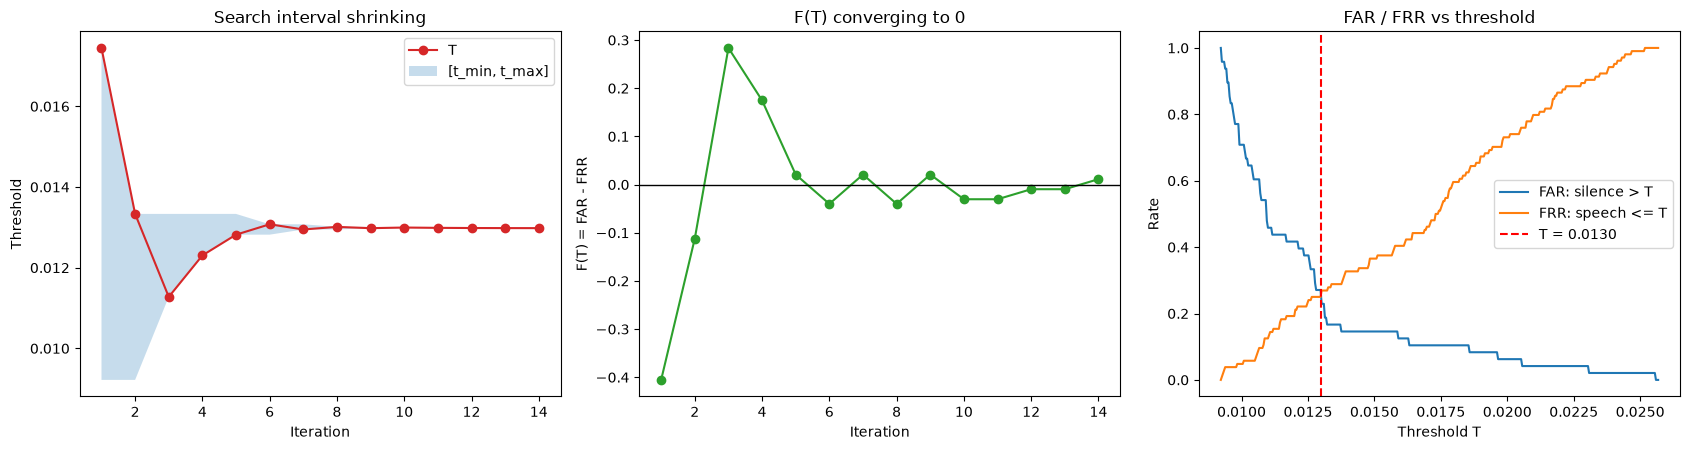

In [15]:
# ---------- Binary search process on the training data ----------

def binary_search_trace(f, g, lo, hi, eps_rel=1e-4, max_iter=60, patience=3):
    """Same as binary_search_threshold but records every iteration for presentation.

    Args:
        f, g (ndarray): speech / silence features inside the overlap region.
        lo, hi (float): ends of the search interval.
        eps_rel, max_iter, patience: as in binary_search_threshold.
    Returns:
        (T_final, history): T_final is the final threshold; history is a list of tuples
        (iteration, T, F(T), t_min, t_max) where t_min/t_max is the interval AFTER the update of that iteration.
    """
    # Initialize the search interval and the first threshold at the midpoint
    t_min, t_max = lo, hi
    eps = eps_rel * (hi - lo)
    T = 0.5 * (t_min + t_max)
    last, same, history = None, 0, []
    for it in range(1, max_iter + 1):
        # Compute F(T), shrink the search interval, then record the state of this iteration
        F, counts = confusion_error(T, f, g)
        if F > 0:
            t_min = T
        else:
            t_max = T
        history.append((it, T, F, t_min, t_max))
        # Stopping conditions identical to binary_search_threshold
        if t_max - t_min < eps:
            break
        same = same + 1 if counts == last else 0
        last = counts
        if same >= patience:
            break
        T = 0.5 * (t_min + t_max)
    return 0.5 * (t_min + t_max), history


# Load the training data and rebuild S (speech frames) and Q (silence frames) with the parameters in use
data_tr = None
if os.path.isdir(TRAIN_DIR):
    train_files, train_labs = find_pairs(TRAIN_DIR)
    data_tr = load_dataset(train_files, train_labs)
    tracks = [compute_feature_track(d["xn"], d["fs"], params["kind"], params["use_log"],
                                    params["smooth_len"]) for d in data_tr]
    S, Q = pooled_class_features(data_tr, tracks)
    lo, hi = find_overlap_region(S, Q)
    f = S[(S >= lo) & (S <= hi)]
    g = Q[(Q >= lo) & (Q <= hi)]

if data_tr is None:
    print("No training data found in '%s': skipping the binary search trace and the training sensitivity cells." % TRAIN_DIR)
elif lo >= hi or len(f) == 0 or len(g) == 0:
    print("The two classes do not overlap: the threshold is the midpoint, so there is no search to plot.")
else:
    # Run the binary search with tracing and compare with the T used in PARAMS
    T_trace, hist = binary_search_trace(f, g, lo, hi)
    print("Overlap region [%.5f, %.5f] | #speech=%d, #silence=%d frames inside the region"
          % (lo, hi, len(f), len(g)))
    print("T (traced) = %.6f | T (PARAMS) = %.6f | difference = %.2e"
          % (T_trace, params["T"], abs(T_trace - params["T"])))

    # Table 4: every iteration (iteration, T, F(T), search interval, interval width)
    rows4 = [[it, T, F, a, b, b - a] for it, T, F, a, b in hist]
    save_table(["iter", "T", "F(T)", "t_min", "t_max", "width"], rows4,
               "table4_binary_search_iterations.csv", "Table 4. Binary search iterations")

    # Figures 3a, 3b: T and the search interval per iteration; F(T) converging to 0
    its = [h[0] for h in hist]
    fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))
    axes[0].plot(its, [h[1] for h in hist], "o-", color="tab:red", label="T")
    axes[0].fill_between(its, [h[3] for h in hist], [h[4] for h in hist], alpha=0.25, label="[t_min, t_max]")
    axes[0].set(xlabel="Iteration", ylabel="Threshold", title="Search interval shrinking")
    axes[0].legend()
    axes[1].plot(its, [h[2] for h in hist], "o-", color="tab:green")
    axes[1].axhline(0, color="black", lw=1)
    axes[1].set(xlabel="Iteration", ylabel="F(T) = FAR - FRR", title="F(T) converging to 0")

    # Figure 3c: FAR(T) and FRR(T) versus threshold; the found threshold lies at their crossing
    Ts = np.linspace(lo, hi, 400)
    far = 1.0 - np.searchsorted(np.sort(g), Ts, side="right") / len(g)   # fraction of silence frames > T
    frr = np.searchsorted(np.sort(f), Ts, side="right") / len(f)         # fraction of speech frames <= T
    axes[2].plot(Ts, far, color="tab:blue", label="FAR: silence > T")
    axes[2].plot(Ts, frr, color="tab:orange", label="FRR: speech <= T")
    axes[2].axvline(T_trace, color="red", ls="--", label="T = %.4f" % T_trace)
    axes[2].set(xlabel="Threshold T", ylabel="Rate", title="FAR / FRR vs threshold")
    axes[2].legend()
    plt.tight_layout()
    save_figure(fig, "fig3_binary_search.png")
    plt.show()

### Meaning of the overlap region, F(T), FAR and FRR

- **FAR (false acceptance):** fraction of silence frames whose feature is above `T` (silence wrongly accepted as speech).
- **FRR (false rejection):** fraction of speech frames whose feature is at or below `T` (speech wrongly rejected as silence).
- `F(T) = FAR - FRR`. It is positive for a low threshold and negative for a high one, so the threshold where it crosses zero is the point where the two error rates are balanced.

Because `F(T)` is monotonic, bisection converges quickly. The search stops when the interval is narrower than `1e-4 x (hi - lo)`, when the counts repeat for several iterations, or after at most 60 iterations.

### How to read the binary search figures

In the left plot the **x-axis** is the iteration number and the shaded band is the search interval `[t_min, t_max]`; it shrinks around the final `T`. The middle plot shows `F(T)` approaching 0. In the right plot, the **FAR** and **FRR** curves cross at the selected threshold (red dashed line).

Since `F(T)` is a step function of `T` (it changes only when `T` passes a frame's feature value), the last iterations oscillate around zero instead of reaching it exactly. This is expected and does not affect the result.


## 9. Threshold and Training Visualization

The following figures show how the shared threshold relates to the training data.

The first figure shows the feature histograms of all speech frames and all silence frames pooled from the training files, together with the threshold `T` (the y-axis is logarithmic). The next cell shows how the training score changes with the smoothing length and with the boundary shift (`trim_on`, `trim_off`).


In [ ]:
# Runs only if training data exists in TRAIN_DIR (otherwise skipped, no error).
if os.path.isdir(TRAIN_DIR):
    # Load the training data and compute the feature track of every file
    train_files, train_labs = find_pairs(TRAIN_DIR)
    data = load_dataset(train_files, train_labs)
    tracks = [compute_feature_track(d["xn"], d["fs"], params["kind"], params["use_log"],
                                    params["smooth_len"]) for d in data]
    S, Q = pooled_class_features(data, tracks)      # S: speech frames, Q: silence frames

    # Plot the feature histograms of the two classes (log y-axis) with the threshold T
    bins = np.linspace(min(S.min(), Q.min()), max(S.max(), Q.max()), 80)
    plt.figure(figsize=(10, 5.5))
    plt.hist(Q, bins=bins, alpha=0.6, color="tab:blue", label="Silence frames")
    plt.hist(S, bins=bins, alpha=0.6, color="tab:orange", label="Speech frames")
    plt.axvline(params["T"], color="red", ls="--", lw=2.5, label="T = %.4f" % params["T"])
    plt.yscale("log")
    # Set labels, title and font sizes; save the image for the slides
    plt.xlabel("%s (smoothed over %d frames)" % (params["kind"], params["smooth_len"]), fontsize=16)
    plt.ylabel("Number of frames (log scale)", fontsize=16)
    plt.title("Shared threshold from %d training signals" % len(data), fontsize=18)
    plt.legend(fontsize=16)
    plt.tick_params(labelsize=14)
    plt.tight_layout()
    os.makedirs(RESULT_DIR, exist_ok=True)
    plt.savefig(os.path.join(RESULT_DIR, "threshold_histogram.png"), dpi=200)   # saved for inserting into the slides
    plt.show()
else:
    print("Training folder '%s' not found: skipping this cell." % TRAIN_DIR)

In [ ]:
# ---------- Hyperparameter grid and effect of boundary shifting (training data) ----------

def grid_search_table(data):
    """Re-run the hyperparameter grid GRID (trim = 0) and return the score of EVERY combination.

    Args:
        data (list[dict]): training data from load_dataset.
    Returns:
        list[list]: each row is [kind, use_log, smooth_len, hyst, min_speech_ms, T, score_ms].
    """
    rows = []
    # Outer loop: compute the features and the threshold T for each (kind, use_log, smooth_len)
    for kind, use_log, sm in itertools.product(GRID["kind"], GRID["use_log"], GRID["smooth_len"]):
        tracks = [compute_feature_track(d["xn"], d["fs"], kind, use_log, sm) for d in data]
        S, Q = pooled_class_features(data, tracks)
        T, sep = train_threshold(S, Q)
        # Inner loop: evaluate every post-processing combination with the objective function
        for hy, ms in itertools.product(GRID["hyst"], GRID["min_speech_ms"]):
            p = {"kind": kind, "use_log": use_log, "smooth_len": sm, "T": float(T),
                 "sep": float(sep), "hyst": hy, "trim_on": 0, "trim_off": 0, "min_speech_ms": ms}
            rows.append([kind, use_log, sm, hy, ms, float(T), objective(data, p)])
    return rows


if data_tr is not None:
    # Table 5: training score of every combination, best first (full CSV, first 10 rows on screen)
    grid_rows = sorted(grid_search_table(data_tr), key=lambda r: r[-1])
    save_table(["kind", "use_log", "smooth_len", "hyst", "min_speech_ms", "T", "train score (ms)"],
               grid_rows, "table5_grid_search.csv", "Table 5. Hyperparameter grid results (trim = 0)",
               max_print=10)

    # Figure 4: best score versus smoothing length, one line per (kind, use_log) pair
    fig, ax = plt.subplots(figsize=(8, 4.8))
    for kind, use_log in itertools.product(GRID["kind"], GRID["use_log"]):
        ys = [min(r[-1] for r in grid_rows if r[0] == kind and r[1] == use_log and r[2] == sm)
              for sm in GRID["smooth_len"]]
        ax.plot(GRID["smooth_len"], ys, "o-", label="%s%s" % (kind, " (log)" if use_log else ""))
    ax.set(xlabel="Smoothing length (frames)", ylabel="Best training score (ms)",
           title="Effect of smoothing length")
    ax.legend()
    plt.tight_layout()
    save_figure(fig, "fig4_grid_smoothing.png")
    plt.show()

    # Table 6 + Figure 5: training score versus (trim_on, trim_off) around the parameters in use
    ton_list, toff_list = list(TRIM_RANGE), list(TRIM_RANGE)
    score_grid = np.array([[objective(data_tr, dict(params, trim_on=a, trim_off=b))
                            for b in toff_list] for a in ton_list])
    rows6 = [[a, b, float(score_grid[i, j])] for i, a in enumerate(ton_list) for j, b in enumerate(toff_list)]
    save_table(["trim_on", "trim_off", "train score (ms)"], rows6,
               "table6_trim_grid.csv", "Table 6. Training score vs boundary shift (10 ms frames)", max_print=10)

    # Heatmap: write the score in every cell and mark the setting used in PARAMS
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(score_grid, cmap="viridis_r", origin="lower")
    for i in range(len(ton_list)):
        for j in range(len(toff_list)):
            dark = score_grid[i, j] > np.median(score_grid)      # dark background -> white text, light -> black
            ax.text(j, i, "%.0f" % score_grid[i, j], ha="center", va="center", fontsize=8,
                    color="white" if dark else "black")
    ax.set_xticks(range(len(toff_list)))
    ax.set_xticklabels(toff_list)
    ax.set_yticks(range(len(ton_list)))
    ax.set_yticklabels(ton_list)
    cur_i, cur_j = ton_list.index(params.get("trim_on", 0)), toff_list.index(params.get("trim_off", 0))
    ax.plot(cur_j, cur_i, "r*", markersize=18, label="PARAMS in use")
    ax.set(xlabel="trim_off (frames)", ylabel="trim_on (frames)", title="Training score (ms) vs boundary trimming")
    fig.colorbar(im, label="score (ms)")
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1))    # legend below the plot so it hides no cell
    plt.tight_layout()
    save_figure(fig, "fig5_trim_heatmap.png")
    plt.show()
    print("Training score of the PARAMS in use: %.2f ms" % objective(data_tr, params))

### From frame decisions to final boundaries

After the threshold is applied, the algorithm has a binary decision for each frame: speech or silence. The post-processing step then:

1. shifts speech onsets later and offsets earlier by `trim_on` / `trim_off` frames (2 frames = 20 ms in the trained parameters);
2. removes speech segments shorter than `min_speech_ms` (50 ms);
3. merges silence gaps shorter than **200 ms**, as required by the assignment.

Finally, the transitions between speech and silence are converted into boundary times. The final figure is therefore the result of the complete pipeline, not just the thresholding stage.


## 10. Final Speech/Silence Segmentation

For every test signal, the figure below contains two panels:

- **Panel 1 - signal and boundaries:** the waveform with the short-time **logSTE** and **logMA** curves (in dB, computed with the 25 ms / 10 ms framing) stacked on top of it. The **blue solid lines** are the boundaries produced by the algorithm and the **red dashed lines** are the ground-truth boundaries from the `.lab` file.
- **Panel 2 - intermediate result:** the smoothed feature used for the decision, the shared threshold `T`, and the frames labeled as speech (light-green background).

The title of each figure reports the quantitative accuracy of that file: **MAE** and **RMSE** in milliseconds, and the number of matched / extra / missing boundaries. The same numbers are listed per boundary in Table 1 and per file in Table 2 (Section 7).

In [ ]:
from matplotlib.lines import Line2D        # build the legend manually for the boundary lines


def short_time_db(xn, fs, win_ms=FRAME_MS, hop_ms=HOP_MS):
    """Short-time logSTE and logMA (dB) on frames of win_ms (default: the assignment's 25 ms / 10 ms).

    Args:
        xn (ndarray): peak-normalized signal.
        fs (int): sampling rate (Hz).
        win_ms (float): window length (ms).
        hop_ms (float): window shift (ms).
    Returns:
        (times, log_ste, log_ma): frame center times (seconds), 10*log10(mean energy)
        and 20*log10(mean absolute amplitude), both in dB.
    """
    # Convert ms to samples; zero-pad if the signal is shorter than one window
    w, h = int(round(win_ms * fs / 1000.0)), int(round(hop_ms * fs / 1000.0))
    if len(xn) < w:
        xn = np.concatenate((xn, np.zeros(w - len(xn))))
    nf = 1 + (len(xn) - w) // h
    starts = np.arange(nf) * h
    ends = starts + w
    # Cumulative sums of |x| and x^2 for fast per-window averages
    c1 = np.concatenate(([0.0], np.cumsum(np.abs(xn))))
    c2 = np.concatenate(([0.0], np.cumsum(xn * xn)))
    ma = (c1[ends] - c1[starts]) / w
    ms = np.maximum(c2[ends] - c2[starts], 0.0) / w
    # Convert to dB (a tiny constant avoids log(0))
    times = (starts + w / 2.0) / fs
    return times, 10.0 * np.log10(ms + 1e-12), 20.0 * np.log10(ma + 1e-12)


def plot_segmentation_result(name, x, fs, gt_b, out, ev, save_path=None):
    """Draw the final segmentation of ONE test file (2 panels).

    Panel 1: waveform with logSTE / logMA (dB) stacked on a second y-axis; blue solid = detected
    boundaries, red dashed = ground-truth boundaries. Panel 2: smoothed decision feature,
    threshold T and the speech background.

    Args:
        name (str): file name (used in the title).
        x (ndarray): raw signal.
        fs (int): sampling rate (Hz).
        gt_b (list[float]): ground-truth boundaries (seconds).
        out (dict): output of BinarySearchAlgorithm.predict.
        ev (dict): output of evaluate_boundaries (mae_ms, rmse_ms, num_matched/extra/missing).
        save_path (str | None): PNG path to save the figure; None = do not save.
    Returns:
        matplotlib.figure.Figure: the figure (already drawn, not yet shown).
    """
    # Prepare the data: detected boundaries (seconds), normalized signal, feature track and speech mask
    det_b = [b / 1000.0 for b in out["boundaries_ms"]]
    xn = out["diagnostics"]["xn"]
    t_feat, mask = out["feature_times"], out["speech_mask"]
    key = list(out["features"])[0]
    dur = len(x) / fs

    # Create the figure with two stacked panels that share the time axis
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7.5), sharex=True,
                                   gridspec_kw={"height_ratios": [1.3, 1.0]})
    fig.suptitle("%s | MAE = %.1f ms | RMSE = %.1f ms | matched/extra/missing = %d/%d/%d"
                 % (name, ev["mae_ms"], ev["rmse_ms"], ev["num_matched"], ev["num_extra"],
                    ev["num_missing"]), fontsize=12)

    # Panel 1a: waveform of the normalized signal (left y-axis)
    ax1.plot(np.arange(len(xn)) / fs, xn, lw=0.5, color="gray", label="waveform")
    ax1.set_ylabel("Amplitude (normalized)")
    ax1.set_title("Signal with short-time logSTE / logMA and boundaries", fontsize=11)

    # Panel 1b: logSTE and logMA (dB) stacked on the same signal using a second y-axis (right)
    t_db, log_ste, log_ma = short_time_db(xn, fs)
    ax1b = ax1.twinx()
    ax1b.plot(t_db, log_ste, color="tab:green", lw=1.4, label="logSTE (dB)")
    ax1b.plot(t_db, log_ma, color="tab:orange", lw=1.4, label="logMA (dB)")
    ax1b.set_ylabel("Level (dB)")

    # Panel 1c: ground-truth boundaries (red dashed) and detected boundaries (blue solid)
    for b in gt_b:
        ax1.axvline(b, color="red", ls="--", lw=1.6)
    for b in det_b:
        ax1.axvline(b, color="blue", ls="-", lw=1.6)
    handles = [Line2D([0], [0], color="gray", lw=1, label="waveform"),
               Line2D([0], [0], color="tab:green", lw=1.4, label="logSTE (dB)"),
               Line2D([0], [0], color="tab:orange", lw=1.4, label="logMA (dB)"),
               Line2D([0], [0], color="red", ls="--", lw=1.6, label="ground truth"),
               Line2D([0], [0], color="blue", ls="-", lw=1.6, label="detected")]
    ax1.legend(handles=handles, loc="upper right", fontsize=8, ncol=5)

    # Panel 2: speech background, smoothed feature, threshold T and both boundary sets
    ax2.fill_between(t_feat, 0, 1, where=mask, step="mid", color="tab:green", alpha=0.15,
                     transform=ax2.get_xaxis_transform())
    ax2.plot(t_feat, out["features"][key], color="black", lw=1.0, label=key + " (smoothed)")
    T = out["thresholds"]["T"]
    ax2.axhline(T, color="purple", lw=1.2, label="threshold T = %.5f" % T)
    for b in gt_b:
        ax2.axvline(b, color="red", ls="--", lw=1.6)
    for b in det_b:
        ax2.axvline(b, color="blue", ls="-", lw=1.6)
    ax2.set_title("Decision feature, threshold and speech region (light green)", fontsize=11)
    ax2.set_ylabel(key)
    ax2.set_xlabel("Time (s)")
    ax2.legend(loc="upper right", fontsize=8)
    ax2.set_xlim(0, dur)

    # Tidy the layout and save the figure if a path is given
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    if save_path:
        fig.savefig(save_path, dpi=200)
    return fig

In [ ]:
# One figure per test file: waveform + logSTE/logMA + boundaries (blue = detected, red = ground truth)
FIG_DIR = RESULT_DIR
os.makedirs(FIG_DIR, exist_ok=True)

for name, (x, fs, gt_b, out) in results.items():
    # Evaluate this file: MAE / RMSE (ms) between the ground-truth and the detected boundaries
    det_b = [b / 1000.0 for b in out["boundaries_ms"]]
    ev = evaluate_boundaries(det_b, gt_b)

    # Draw and save the figure of this file, then display it
    png = os.path.join(FIG_DIR, "figure_%s.png" % os.path.splitext(name)[0])
    plot_segmentation_result(name, x, fs, gt_b, out, ev, save_path=png)
    plt.show()

    # Print the boundary times (ms) next to the figure for the quantitative comparison
    print("%s | GT (ms): %s | detected (ms): %s | MAE = %.2f ms, RMSE = %.2f ms"
          % (name, [round(b * 1000, 1) for b in gt_b], [round(b * 1000, 1) for b in det_b],
             ev["mae_ms"], ev["rmse_ms"]))

### Mask after each processing stage

The next figure shows the speech labels after every stage of the pipeline: ground truth, raw threshold decision, boundary shift + minimum speech length, and the final result after filling silence shorter than 200 ms.


In [ ]:
lab_of = {os.path.basename(w): l for w, l in zip(test_files, test_labs)}   # file name -> .lab file

# ---------- Boundary errors and mask stages on the test set ----------

# Figure 1: signed error of every boundary (positive = predicted boundary later than ground truth)
labels = ["%s #%d" % (r[0].replace(".wav", ""), r[1]) for r in rows1]
errs = [r[4] for r in rows1]
fig, ax = plt.subplots(figsize=(10, 4.5))
bars = ax.bar(range(len(errs)), errs, color=["tab:red" if e > 0 else "tab:blue" for e in errs])
# Write the value on every bar, draw the zero line and the mean-error line
for i, e in enumerate(errs):
    ax.text(i, e + (1.0 if e >= 0 else -1.0), "%.1f" % e, ha="center",
            va="bottom" if e >= 0 else "top", fontsize=9)
ax.axhline(0, color="black", lw=1)
ax.axhline(np.mean(errs), color="gray", ls="--", label="Mean error = %.1f ms" % np.mean(errs))
# Set axis labels and the title (with overall MAE/RMSE), then save the figure
ax.set_xticks(range(len(errs)))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_ylabel("Error = detected - ground truth (ms)")
ax.set_title("Boundary errors on test set | MAE = %.2f ms, RMSE = %.2f ms"
             % (calculate_mae(abs_all), calculate_rmse(abs_all)))
ax.legend()
plt.tight_layout()
save_figure(fig, "fig1_boundary_errors.png")
plt.show()

# Figure 2: speech labels after each processing stage (ground truth -> threshold -> trim/filter -> fill silence)
stages = [("Ground truth", None), ("1. Threshold (mask_raw)", "mask_raw"),
          ("2. Trim + min speech (mask_exp)", "mask_exp"), ("3. Fill silence < 200 ms (final)", "speech_mask")]
fig, axes = plt.subplots(len(results), 1, figsize=(12, 2.6 * len(results)), sharex=False)
axes = np.atleast_1d(axes)
for ax, (name, (x, fs, gt_b, out)) in zip(axes, results.items()):
    t = out["feature_times"]
    gt_mask = lab_frame_mask(read_lab(lab_of[name]), t)
    # Every stage is a colored strip at its own y level (stacked from top to bottom)
    for row, (label, key) in enumerate(stages):
        mask = gt_mask if key is None else (out["speech_mask"] if key == "speech_mask"
                                            else out["diagnostics"][key])
        y0 = len(stages) - 1 - row
        ax.fill_between(t, y0, y0 + 0.8, where=mask, step="mid",
                        color="tab:red" if key is None else "tab:blue", alpha=0.7)
    # Y tick labels = stage names, title = file name
    ax.set_yticks([len(stages) - 1 - i + 0.4 for i in range(len(stages))])
    ax.set_yticklabels([s[0] for s in stages], fontsize=8)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Time (s)")
    ax.set_xlim(0, len(x) / fs)          # show the full file length (including silence at both ends)
plt.tight_layout()
save_figure(fig, "fig2_mask_stages.png")
plt.show()

### Interpreting the differences between recordings

The Binary Search method uses **one fixed threshold** learned from the training signals. It does not re-estimate the threshold for each recording, so differences in microphone, background noise and speaker can shift the feature values relative to `T`.

In this experiment, every test file produces exactly the expected number of boundaries (no Missing and no Extra). The remaining errors are small shifts of the boundary position. The largest single error is the first boundary of `phone_F2` (detected 37.5 ms later than the ground truth), and the phone recordings have the larger per-file MAE/RMSE than `studio_M2`.

This is an experimental observation from the current four-file test set, not a claim that every phone recording will be harder than every studio recording: `studio_F2` (MAE 17.51 ms) is close to `phone_F2` (MAE 20.00 ms).


## 11. Discussion

The results show that the Binary Search method locates the speech boundaries accurately on the four test signals.

All 8 ground-truth boundaries are matched, with no Missing and no Extra boundaries. The pooled error is **13.13 ms MAE** and **17.14 ms RMSE**, which is on the order of one to two analysis frames (the frame shift is 10 ms). At frame level, the pooled accuracy is 0.992 and the F1 score of the speech class is 0.994.

The signed errors have different directions in different files (for example `phone_F2` is detected later on average, `studio_F2` earlier), and the mean signed error over all boundaries is close to zero. The shared `trim_on` / `trim_off` shift therefore balances the early and late errors on average, but cannot correct each file individually.

The experiment also shows the limitation of a single fixed threshold: it is simple and fast, but it depends on the training signals being representative of the test recordings.


### Main takeaway

The experiment confirms the complete operation of the Binary Search approach: energy feature extraction, smoothing, overlap-region analysis, threshold search by bisection, frame classification, post-processing, and boundary evaluation.

The results also show an important limitation: the threshold is fixed after training, so the quality of the final segmentation depends on how well the training data represents the test conditions. With only four test files, the conclusions are indicative rather than statistically conclusive.


## 12. Conclusion

The Binary Search-based speech/silence segmentation method was implemented and evaluated on four test signals.

The method uses a smoothed **mean absolute amplitude** feature. A single shared threshold is found by binary search on the overlap region of the speech and silence feature distributions of the training set, and is then applied unchanged to the test set. Post-processing shifts the boundaries, removes very short speech segments and merges silence shorter than 200 ms.

The final performance is evaluated using **MAE** and **RMSE** of the detected speech boundaries.

For the current test set, the pooled performance over the 8 boundaries is:

- **MAE: 13.13 ms**
- **RMSE: 17.14 ms**
- **Missing: 0, Extra: 0**

The experiment also shows that performance depends on the characteristics and recording conditions of the input signals.


### Submission note

The notebook contains the executable code together with the displayed experimental outputs, so the results can be inspected without waiting for a new execution during the presentation. All project code is included in this single notebook.


## 13. Reproducibility Note

This notebook is intended to be submitted with its execution outputs already stored.

The WAV/LAB signal files (`data/TinHieuHuanLuyen`, `data/TinHieuKiemThu`) and the Python virtual environment are **not included in the submission folder**, in accordance with the project submission requirement. To re-run the notebook, edit `TRAIN_DIR`, `TEST_DIR` and `PARAMS_PATH` in Section 3.1 and choose *Kernel -> Restart & Run All*.
